In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

In [2]:
import numpy as np
from sklearn.metrics import accuracy_score
from tscglue.models import LokyStackerV10FM
from tscglue import data_loader
import polars as pl
from sklearn.metrics import log_loss

In [3]:
dataset = "Worms"
# dataset = 'Car'
# dataset = 'HandOutlines'
#dataset = 'Trace'
#dataset = 'SwedishLeaf'
#dataset = 'Meat'
# dataset='ACSF1'
# dataset='MedicalImages'
X_train, y_train, X_test, y_test = data_loader.load_fold(dataset, 19)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(181, 1, 900) (181,) (77, 1, 900) (77,)


In [4]:
seed = 2683

In [5]:
from tscglue.models import LokyStackerV10RSTSFRandom


m = LokyStackerV10RSTSFRandom(random_state=seed, n_jobs=16, keep_features=True, verbose=10, n_repetitions=3)

In [6]:
m.fit(X_train, y_train)

[0.00s] Starting fit, run_dir=tscglue_runs/7977066313734460, n_jobs=16
[0.00s] Saved X and y to disk in 0.00s (dtype=float64)
[subprocess] fit_transform multirocket_s_1675711793: 1.6267s
[6.23s] Fit+transformed multirocket_s_1675711793 features (181, 49728) (68.67 MB) dtype=float64 in 6.1321s
[subprocess] fit_transform hydra_s_2109509380: 1.7642s
[12.36s] Fit+transformed hydra_s_2109509380 features (181, 7168) (9.90 MB) dtype=float64 in 6.1213s
[subprocess] fit_transform quant: 0.3672s
[16.30s] Fit+transformed quant features (181, 7987) (11.03 MB) dtype=float64 in 3.9420s
[subprocess] fit_transform rdst_s_1973074453: 7.0292s
[27.04s] Fit+transformed rdst_s_1973074453 features (181, 30000) (41.43 MB) dtype=float64 in 10.7468s
[subprocess] fit_transform rstsf-random_s_447740098: 24.7116s
[58.54s] Fit+transformed rstsf-random_s_447740098 features (181, 13622) (18.81 MB) dtype=float64 in 31.4954s
[subprocess] fit_transform mantis: 2.1845s
[67.32s] Fit+transformed mantis features (181, 512)

,random_state,2683
,k_folds,10
,n_jobs,16
,keep_features,True
,verbose,10
,model_names,None
,n_repetitions,3
,feature_dtype,dtype('float64')


In [7]:
m.classes_

array(['1', '2', '3', '4', '5'], dtype='<U1')

In [8]:
y_pred = m.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on {dataset}: {acc}")

[0.00s] Starting prediction
[subprocess] transform multirocket_s_1675711793: 0.6079s
[7.71s] Computed multirocket_s_1675711793 features (77, 49728) (29.21 MB) dtype=float64 in 7.6568s
[subprocess] transform hydra_s_2109509380: 0.6718s
[11.59s] Computed hydra_s_2109509380 features (77, 7168) (4.21 MB) dtype=float64 in 3.8809s
[subprocess] transform quant: 0.2509s
[15.48s] Computed quant features (77, 7987) (4.69 MB) dtype=float64 in 3.8855s
[subprocess] transform rdst_s_1973074453: 2.1014s
[21.01s] Computed rdst_s_1973074453 features (77, 30000) (17.62 MB) dtype=float64 in 5.5327s
[subprocess] transform rstsf-random_s_447740098: 21.2231s
[49.30s] Computed rstsf-random_s_447740098 features (77, 13622) (8.00 MB) dtype=float64 in 28.2898s
[subprocess] transform mantis: 1.6374s
[57.38s] Computed mantis features (77, 512) (0.30 MB) dtype=float64 in 8.0790s
[subprocess] transform chronos2: 5.8089s
[69.74s] Computed chronos2 features (77, 1536) (0.90 MB) dtype=float64 in 12.3551s
[69.74s] Comp

In [9]:
proba = m.predict_proba(X_test)
classes = list(m.classes_)

print(f"Log-loss: {log_loss(y_test, proba, labels=classes):.4f}")
# print(f"AUC (OvR): {roc_auc_score(y_test, proba, multi_class='ovr', labels=classes):.4f}")

[0.00s] Starting prediction
[subprocess] transform multirocket_s_1675711793: 0.6088s
[4.99s] Computed multirocket_s_1675711793 features (77, 49728) (29.21 MB) dtype=float64 in 4.9459s
[subprocess] transform hydra_s_2109509380: 0.6223s
[9.15s] Computed hydra_s_2109509380 features (77, 7168) (4.21 MB) dtype=float64 in 4.1606s
[subprocess] transform quant: 0.2530s
[13.05s] Computed quant features (77, 7987) (4.69 MB) dtype=float64 in 3.8957s
[subprocess] transform rdst_s_1973074453: 2.0099s
[18.40s] Computed rdst_s_1973074453 features (77, 30000) (17.62 MB) dtype=float64 in 5.3501s
[subprocess] transform rstsf-random_s_447740098: 20.7439s
[45.35s] Computed rstsf-random_s_447740098 features (77, 13622) (8.00 MB) dtype=float64 in 26.9483s
[subprocess] transform mantis: 1.5876s
[53.09s] Computed mantis features (77, 512) (0.30 MB) dtype=float64 in 7.7361s
[subprocess] transform chronos2: 5.9601s
[65.68s] Computed chronos2 features (77, 1536) (0.90 MB) dtype=float64 in 12.5987s
[65.68s] Compu

In [10]:
pl.DataFrame(m.neki)

index,model,level,class,probability
i64,str,i64,str,f64
0,"""multirockethydra-bestk-p-ridge…",0,"""1""",0.438726
0,"""multirockethydra-bestk-p-ridge…",0,"""2""",0.24501
0,"""multirockethydra-bestk-p-ridge…",0,"""3""",0.120792
0,"""multirockethydra-bestk-p-ridge…",0,"""4""",0.092509
0,"""multirockethydra-bestk-p-ridge…",0,"""5""",0.102962
…,…,…,…,…
177,"""probability-ridgecv""",1,"""1""",1.0
177,"""probability-ridgecv""",1,"""2""",0.0
177,"""probability-ridgecv""",1,"""3""",0.0


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TS

[0.00s] Starting prediction


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[subprocess] transform multirocket_s_1675711793: 0.6328s
[4.96s] Computed multirocket_s_1675711793 features (77, 49728) (29.21 MB) dtype=float64 in 4.9180s
[subprocess] transform hydra_s_2109509380: 2.2346s
[11.51s] Computed hydra_s_2109509380 features (77, 7168) (4.21 MB) dtype=float64 in 6.5502s
[subprocess] transform quant: 2.1011s
[18.56s] Computed quant features (77, 7987) (4.69 MB) dtype=float64 in 7.0540s
[subprocess] transform rdst_s_1973074453: 2.0571s
[24.85s] Computed rdst_s_1973074453 features (77, 30000) (17.62 MB) dtype=float64 in 6.2858s
[subprocess] transform rstsf-random_s_447740098: 20.8393s
[52.79s] Computed rstsf-random_s_447740098 features (77, 13622) (8.00 MB) dtype=float64 in 27.9406s
[subprocess] transform mantis: 1.7045s
[61.19s] Computed mantis features (77, 512) (0.30 MB) dtype=float64 in 8.4037s
[subprocess] transform chronos2: 6.5301s
[74.46s] Computed chronos2 features (77, 1536) (0.90 MB) dtype=float64 in 13.2675s
[74.46s] Computed and saved features for 

/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


RidgeCV   OOF mean=0.7700 std=0.0091  test=0.7792
RF        OOF mean=0.7708 std=0.0078  test=0.8052
HGBT      OOF mean=0.7646 std=0.0076  test=0.7143
MLP       OOF mean=0.7777 std=0.0135  test=0.8052


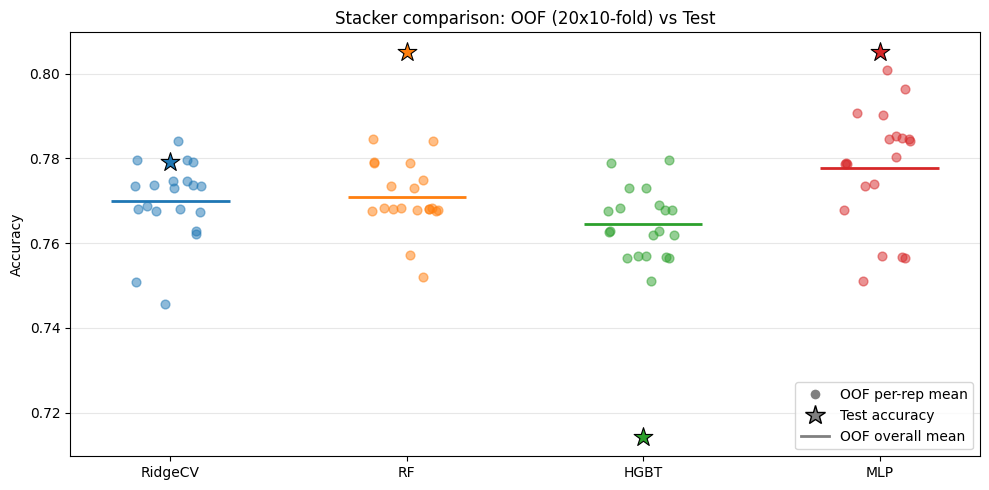

In [11]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Build probability matrix from level-0 neki predictions
df = pl.DataFrame(m.neki).filter(pl.col("level") == 0)
prob_matrix = df.pivot(on="class", index=["index", "model"], values="probability", aggregate_function='mean')
class_cols = [c for c in prob_matrix.columns if c not in ("index", "model")]
wide = prob_matrix.pivot(on="model", index="index", values=class_cols)
wide = wide.sort("index")
X_stack = wide.drop("index").to_numpy()

le = LabelEncoder()
y_enc = le.fit_transform(y_train)

stackers = {
    "RidgeCV": RidgeClassifierCV(alphas=np.logspace(-3, 3, 20)),
    "RF": RandomForestClassifier(n_estimators=200, n_jobs=-1),
    "HGBT": HistGradientBoostingClassifier(max_iter=200),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500),
}

N_REPEATS = 20
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=N_REPEATS, random_state=42)
results = {name: [] for name in stackers}

for fold_i, (tr_idx, val_idx) in enumerate(rskf.split(X_stack, y_enc)):
    rep = fold_i // 10
    for name, clf in stackers.items():
        clf_copy = clf.__class__(**clf.get_params())
        clf_copy.fit(X_stack[tr_idx], y_enc[tr_idx])
        acc = accuracy_score(y_enc[val_idx], clf_copy.predict(X_stack[val_idx]))
        results[name].append({"rep": rep, "fold": fold_i % 10, "acc": acc})

# Build test probability matrix
test_preds = m.predict_proba_per_model(X_test)
train_cols = wide.drop("index").columns

test_records = []
for model_name, proba_arr in test_preds.items():
    if model_name in m.stacking_models:
        continue
    classes_ = list(m.classes_)
    for i in range(proba_arr.shape[0]):
        for j, cls in enumerate(classes_):
            test_records.append({"index": i, "model": model_name, "level": 0, "class": str(cls), "probability": proba_arr[i, j]})

df_test = pl.DataFrame(test_records)
prob_matrix_test = df_test.pivot(on="class", index=["index", "model"], values="probability")
class_cols_test = [c for c in prob_matrix_test.columns if c not in ("index", "model")]
wide_test = prob_matrix_test.pivot(on="model", index="index", values=class_cols_test)
wide_test = wide_test.sort("index")
X_stack_test = wide_test.select(train_cols).to_numpy()
y_test_enc = le.transform(y_test)

# Test set accuracy
test_accs = {}
for name, clf in stackers.items():
    clf_final = clf.__class__(**clf.get_params())
    clf_final.fit(X_stack, y_enc)
    test_accs[name] = accuracy_score(y_test_enc, clf_final.predict(X_stack_test))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
names = list(stackers.keys())
x_positions = np.arange(len(names))

for i, name in enumerate(names):
    rdf = pl.DataFrame(results[name])
    per_rep = rdf.group_by("rep").agg(pl.col("acc").mean()).sort("rep")["acc"].to_numpy()
    # scatter all per-rep OOF accuracies
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(per_rep))
    ax.scatter(np.full_like(per_rep, i) + jitter, per_rep, alpha=0.5, s=40, zorder=3, label=f"{name} OOF reps" if i == 0 else None, color=f"C{i}")
    # mean OOF line
    ax.hlines(per_rep.mean(), i - 0.25, i + 0.25, colors=f"C{i}", linewidths=2, zorder=4)
    # test accuracy marker
    ax.scatter(i, test_accs[name], marker="*", s=200, color=f"C{i}", edgecolors="black", linewidths=0.8, zorder=5)
    print(f"{name:8s}  OOF mean={per_rep.mean():.4f} std={per_rep.std():.4f}  test={test_accs[name]:.4f}")

ax.set_xticks(x_positions)
ax.set_xticklabels(names)
ax.set_ylabel("Accuracy")
ax.set_title(f"Stacker comparison: OOF ({N_REPEATS}x10-fold) vs Test")
# custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="OOF per-rep mean"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray", markeredgecolor="black", markersize=15, label="Test accuracy"),
    Line2D([0], [0], color="gray", linewidth=2, label="OOF overall mean"),
]
ax.legend(handles=legend_elements, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
